# 239. Laptop scale on Swiss-Prot, against the right competitors (experiment 4)

The claim behind the LMIC framing is that kmerseek runs where the alternatives do not:
a laptop, no cluster, no dependence on anyone. The experiment brief's kill condition: if
MMseqs2 or DIAMOND fits the same memory at the same scale, cost is a property, not a
claim. DIAMOND is the reduced-alphabet-seed tool every reviewer will name; it was not
in the benchmark until now.

Setup (`scripts/laptop_scale_benchmark.sh`): Swiss-Prot 2026_03 (575,748 sequences,
209 M residues) indexed and searched with 1,000 random queries from itself, on this
16-core Mac, every number from `/usr/bin/time -l`. kmerseek is the scratch integration
of PR #50 (`--scaled`) and PR #54 (extension, chaining, E-value): `hp_thomas_dill2`,
k=15, `--scaled 10`, `--extend-mismatch-penalty 2`, default search filters. MMseqs2 18
`-s 5.7` (default sensitivity) with a prebuilt index; DIAMOND 2.2.6 `--sensitive`.
A 16 GB laptop is the bar.

shape: (6, 7)
┌─────────────────┬────────┬────────┬─────────────┬───────────────┬───────────────┬────────────────┐
│ tool            ┆ stage  ┆ wall_s ┆ peak_rss_gb ┆ index_size_gb ┆ queries_per_s ┆ pairs_reported │
│ ---             ┆ ---    ┆ ---    ┆ ---         ┆ ---           ┆ ---           ┆ ---            │
│ str             ┆ str    ┆ f64    ┆ f64         ┆ f64           ┆ f64           ┆ i64            │
╞═════════════════╪════════╪════════╪═════════════╪═══════════════╪═══════════════╪════════════════╡
│ kmerseek hp k15 ┆ index  ┆ 17.97  ┆ 8.12        ┆ 1.26          ┆ null          ┆ null           │
│ scaled10        ┆        ┆        ┆             ┆               ┆               ┆                │
│ kmerseek hp k15 ┆ search ┆ 436.85 ┆ 82.68       ┆ null          ┆ 2.289115      ┆ 55670655       │
│ scaled10        ┆        ┆        ┆             ┆               ┆               ┆                │
│ MMseqs2 -s 5.7  ┆ index  ┆ 7.94   ┆ 2.65        ┆ 2.75          ┆ null     

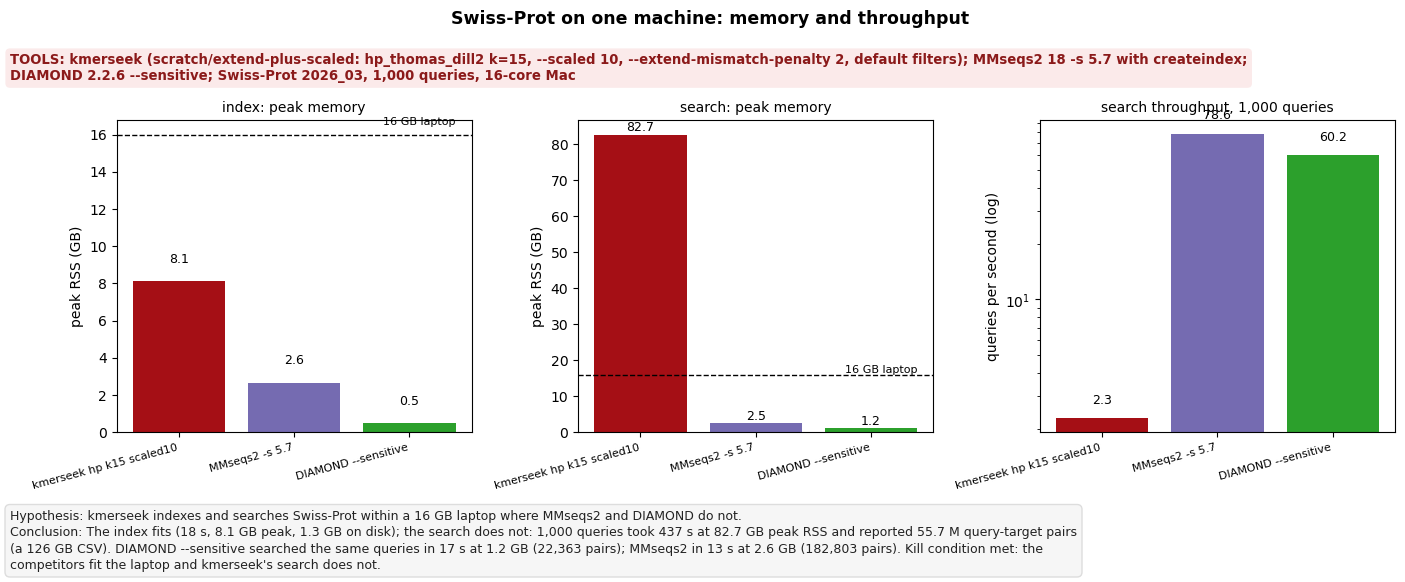

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

sys.path.insert(0, str(Path.cwd()))
import hp_conservation_utils as hc

FIG = Path("../figures")
rows = [
    # tool, stage, wall_s, peak_rss_gb, size_gb, queries_per_s, pairs_reported
    ("kmerseek hp k15 scaled10", "index", 17.97, 8.12, 1.26, None, None),
    ("kmerseek hp k15 scaled10", "search", 436.85, 82.68, None, 1000 / 436.85, 55_670_655),
    ("MMseqs2 -s 5.7", "index", 0.73 + 7.21, 2.65, 2.75, None, None),
    ("MMseqs2 -s 5.7", "search", 12.73, 2.55, None, 1000 / 12.73, 182_803),
    ("DIAMOND --sensitive", "index", 0.99, 0.47, 0.27, None, None),
    ("DIAMOND --sensitive", "search", 16.62, 1.16, None, 1000 / 16.62, 22_363),
]
t = pl.DataFrame(rows, schema=["tool", "stage", "wall_s", "peak_rss_gb", "index_size_gb", "queries_per_s", "pairs_reported"], orient="row")
print(t)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
tools = ["kmerseek hp k15 scaled10", "MMseqs2 -s 5.7", "DIAMOND --sensitive"]
col = {"kmerseek hp k15 scaled10": "#a50f15", "MMseqs2 -s 5.7": "#756bb1", "DIAMOND --sensitive": "#2ca02c"}
for ax, stage in zip(axes[:2], ["index", "search"]):
    s = t.filter(pl.col("stage") == stage)
    ax.bar(range(3), [s.filter(pl.col("tool") == x)["peak_rss_gb"][0] for x in tools], color=[col[x] for x in tools])
    ax.axhline(16, color="k", ls="--", lw=1)
    ax.text(2.4, 16.5, "16 GB laptop", ha="right", fontsize=8)
    ax.set_xticks(range(3), tools, rotation=15, ha="right", fontsize=8)
    ax.set_ylabel("peak RSS (GB)")
    ax.set_title(f"{stage}: peak memory", fontsize=10)
    for i, x in enumerate(tools):
        v = s.filter(pl.col("tool") == x)["peak_rss_gb"][0]; ax.text(i, v + 1, f"{v:.1f}", ha="center", fontsize=9)
ax = axes[2]
s = t.filter(pl.col("stage") == "search")
ax.bar(range(3), [s.filter(pl.col("tool") == x)["queries_per_s"][0] for x in tools], color=[col[x] for x in tools])
ax.set_yscale("log")
ax.set_xticks(range(3), tools, rotation=15, ha="right", fontsize=8)
ax.set_ylabel("queries per second (log)")
ax.set_title("search throughput, 1,000 queries", fontsize=10)
for i, x in enumerate(tools):
    v = s.filter(pl.col("tool") == x)["queries_per_s"][0]; ax.text(i, v * 1.2, f"{v:.1f}", ha="center", fontsize=9)
hc.finish_figure(
    fig, FIG / "239_laptop_scale_swissprot.png",
    tools="kmerseek (scratch/extend-plus-scaled: hp_thomas_dill2 k=15, --scaled 10, --extend-mismatch-penalty 2, default filters); MMseqs2 18 -s 5.7 with createindex; DIAMOND 2.2.6 --sensitive; Swiss-Prot 2026_03, 1,000 queries, 16-core Mac",
    hypothesis="kmerseek indexes and searches Swiss-Prot within a 16 GB laptop where MMseqs2 and DIAMOND do not.",
    conclusion=("The index fits (18 s, 8.1 GB peak, 1.3 GB on disk); the search does not: 1,000 queries took 437 s at 82.7 GB peak RSS and reported 55.7 M query-target pairs (a 126 GB CSV). "
                "DIAMOND --sensitive searched the same queries in 17 s at 1.2 GB (22,363 pairs); MMseqs2 in 13 s at 2.6 GB (182,803 pairs). Kill condition met: the competitors fit the laptop and kmerseek's search does not."),
    title="Swiss-Prot on one machine: memory and throughput",
)

## Verdict

The kill condition fired, and not narrowly. `--scaled 10` makes the index laptop-sized
(8 GB to build, 1.3 GB on disk), but the search holds every candidate pair and every
region in memory and writes them all: 55.7 million pairs for 1,000 queries, 83 GB peak,
2.3 queries per second. DIAMOND at `--sensitive` does the same job at 1.2 GB and 60
queries per second; MMseqs2 at 2.6 GB and 79 per second. Both fit a laptop. Cost is not
a claim until the search side is bounded: a seed budget or two-hit rule before extension,
an E-value cutoff at output rather than a Poisson one, and streaming results instead of
holding them. Those are engineering, and the numbers above are the target.

What is not measured here: sensitivity at this scale (the three tools report 250x
different pair counts and are not at matched recall), and the scaled-index cost in
recall (PR #50's region-survival arithmetic says short matches go first).